/tmp/ipykernel_1361343/271597278.py:87: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


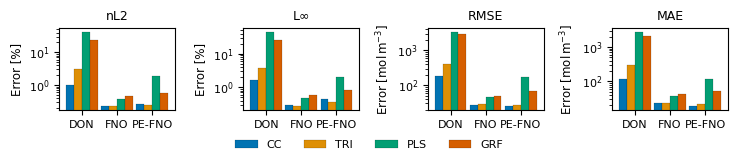

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as mticker

# ────────────────────────────────────────────────────────────────
# Data
models   = ['DON', 'FNO', 'PE-FNO']
datasets = ['CC', 'TRI', 'PLS', 'GRF']          # colour groups

metric_data = {
    # Normalised L2  [%]
    'nL2': np.array([
        [ 1.0158, 0.2389, 0.2660],   # CC
        [ 3.1789, 0.2283, 0.2498],   # TRI
        [41.6482, 0.3803, 1.8947],   # PLS
        [23.9029, 0.4566, 0.5803],   # GRF
    ]),
    # L∞  [%]
    'L∞': np.array([
        [ 1.6622, 0.3058, 0.4404],
        [ 3.7067, 0.2738, 0.3636],
        [44.3150, 0.4677, 2.0326],
        [26.0170, 0.5693, 0.8339],
    ]),
    # RMSE  [mol m⁻³]
    'RMSE': np.array([
        [ 177.8572,   27.6904,   24.9477],
        [ 405.3195,   28.0721,   26.6848],
        [3334.5110,   44.7368,  173.6969],
        [2833.6387,   50.4013,   66.2096],
    ]),
    # MAE  [mol m⁻³]
    'MAE': np.array([
        [ 116.2145,  22.8781,  19.0116],
        [ 306.8013,  23.2608,  21.5729],
        [2713.8989,  38.0004, 113.5471],
        [2120.9224,  42.8991,  52.6148],
    ])
}

# ────────────────────────────────────────────────────────────────
# (everything that follows stays exactly the same)
# Appearance settings
pred_cols = sns.color_palette("colorblind", len(datasets))
label_col = dict(zip(datasets, pred_cols))

mm_to_in = 1 / 25.4
fig_w = 190 * mm_to_in          # 7.48 in
fig_h = fig_w * 0.2             # 45 % of width  → 3.37 in

fig, axs = plt.subplots(1, 4, figsize=(fig_w, fig_h), constrained_layout=True)
axs = axs.ravel()

# 2.  BAR WIDTHS — fill ~90 % of each model slot
cluster_frac = 0.9
bar_width = cluster_frac / len(datasets)
offsets = (np.arange(len(datasets)) - (len(datasets) - 1) / 2) * bar_width

for ax, (metric_name, values) in zip(axs, metric_data.items()):
    x = np.arange(len(models))
    for i, ds in enumerate(datasets):
        ax.bar(x + offsets[i], values[i],
               width=bar_width, color=label_col[ds],
               edgecolor='black', linewidth=0.1,
               label=ds if ax is axs[0] else "_nolegend_")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

    if metric_name in ['nL2', 'L∞']:
        ax.set_ylabel(r'Error [%]', fontsize=8.5)
    else:                       # RMSE & MAE
        ax.set_ylabel(r'Error [$\mathrm{mol\,m^{-3}}$]', fontsize=8.5)

    ax.set_yscale('log')
    ax.set_title(metric_name, fontsize=9)
    ax.margins(x=0.07)

# Shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=len(datasets), frameon=False, fontsize=8,
           bbox_to_anchor=(0.5, -0.1))

fig.tight_layout()
fig.savefig('error_metrics_comparison_con12.svg', dpi=1200, bbox_inches='tight')
plt.show()


/tmp/ipykernel_1361343/3965548798.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


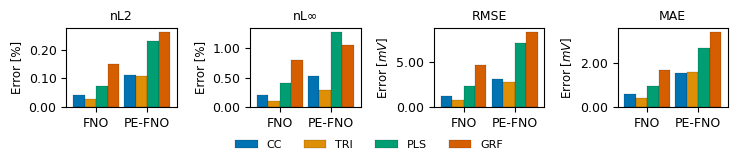

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as mticker

# ────────────────────────────────────────────────────────────────
# Data
models   = ['FNO', 'PE-FNO']
datasets = ['CC', 'TRI', 'PLS', 'GRF']          # colour groups

metric_data = {
    'nL2': np.array([
        [0.0406, 0.1128],   # CC
        [0.0267, 0.1070],   # TRI
        [0.0723, 0.2311],   # PLS
        [0.1499, 0.2617],   # GRF
    ]),
    # L∞  [%]
    'nL∞': np.array([
        [0.2060, 0.5254],
        [0.1014, 0.2916],
        [0.4113, 1.2746],
        [0.8014, 1.0562],
    ]),
    # RMSE  [mV]
    'RMSE': np.array([
        [1.2277,  3.0733],
        [0.7538,  2.7289],
        [2.2964,  7.0933],
        [4.6693,  8.3626],
    ]),
    # MAE  [mV]
    'MAE': np.array([
        [0.5654, 1.5388],
        [0.4200, 1.5633],
        [0.9337, 2.6966],
        [1.6863, 3.4005],
    ])
}

# ────────────────────────────────────────────────────────────────
# Appearance settings
pred_cols = sns.color_palette("colorblind", len(datasets))
label_col = dict(zip(datasets, pred_cols))

# 1.  FIGURE SIZE — keep width 190 mm but give it some height
mm_to_in = 1 / 25.4
fig_w = 190 * mm_to_in          # 7.48 in
fig_h = fig_w * 0.2             # 45 % of width  → 3.37 in

fig, axs = plt.subplots(
    1, 4, figsize=(fig_w, fig_h),
    constrained_layout=True      # let MPL do the spacing
)
axs = axs.ravel()

# ────────────────────────────────────────────────────────────────
# 2.  BAR WIDTHS — fill ~90 % of each model slot
cluster_frac = 0.9                      # 1.0 → bars touch neighbouring cluster
bar_width = cluster_frac / len(datasets)
offsets = (np.arange(len(datasets)) -
           (len(datasets) - 1) / 2) * bar_width

for ax, (metric_name, values) in zip(axs, metric_data.items()):
    x = np.arange(len(models))

    # grouped bars
    for i, ds in enumerate(datasets):
        ax.bar(x + offsets[i], values[i],
               width=bar_width,
               color=label_col[ds],
               edgecolor='black', linewidth=0.1,
               label=ds if ax is axs[0] else "_nolegend_")

    # cosmetics ---------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)       # tick labels size
    ax.tick_params(axis='y', labelsize=9)        # y-tick labels size

    if metric_name in ['nL2', 'nL∞']:
        ax.set_ylabel(r'Error [%]',  fontsize=8.5)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    else:  # RMSE & MAE
        ax.set_ylabel(r'Error [$mV$]', fontsize=8.5)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    ax.set_title(metric_name, fontsize=9)
    ax.margins(x=0.07)                           # breathing-room

# ────────────────────────────────────────────────────────────────
# One shared legend centred below everything
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),           # drop a bit lower
           ncol=len(datasets),
           frameon=False,
           fontsize=8)

# leave space at the bottom for the legend
fig.tight_layout()
fig.align_ylabels()
fig.savefig('error_metrics_comparison_voltage12.svg', dpi=1200, bbox_inches='tight')
plt.show()


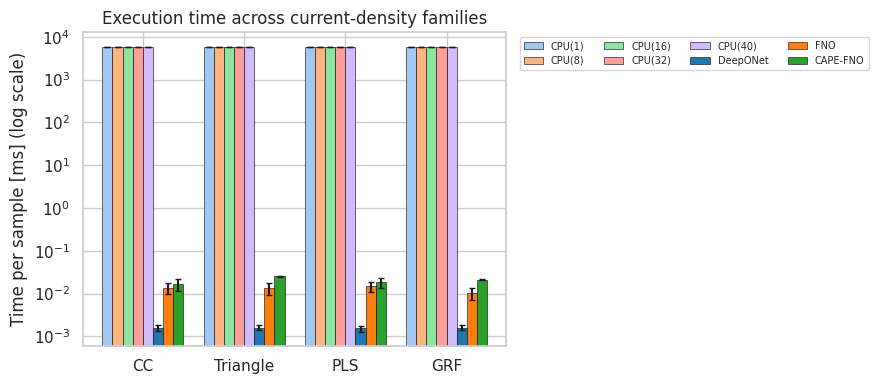

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ──────────────────────────────────────────────────────────────
# ❶  DATA  — all in *milliseconds* so a common log-scale makes sense
families = ['CC', 'Triangle', 'PLS', 'GRF']

means_ms = {                      # mean ± std (already ms)
    'DeepONet': np.array([0.00160113, 0.00160004, 0.00153836, 0.00160817]),
    'FNO'     : np.array([0.01356569, 0.01327769, 0.01473285, 0.01014182]),
    'CAPE-FNO': np.array([0.01685495, 0.02564206, 0.01851366, 0.02103266]),
}
stds_ms = {
    'DeepONet': np.array([0.00024832, 0.00021008, 0.00023807, 0.00021681]),
    'FNO'     : np.array([0.00394258, 0.00406557, 0.00383702, 0.00320999]),
    'CAPE-FNO': np.array([0.00547225, 0.00066192, 0.00505883, 0.00051143]),
}

# CPU numbers (5.87 s ± 0.05 s)  →  ms
cpu_labels  = ['CPU(1)', 'CPU(8)', 'CPU(16)', 'CPU(32)', 'CPU(40)']
cpu_mean_ms = 5.87 * 1000        # 5 870 ms
cpu_std_ms  = 0.05 * 1000        # 50 ms
cpu_means_ms = {lbl: np.full(len(families), cpu_mean_ms) for lbl in cpu_labels}
cpu_stds_ms  = {lbl: np.full(len(families), cpu_std_ms)  for lbl in cpu_labels}

# plot order & colours
all_labels = cpu_labels + list(means_ms.keys())       # 8 bars per family
n_bars     = len(all_labels)
palette    = (sns.color_palette("pastel", n_colors=len(cpu_labels)) +
              sns.color_palette("tab10",  n_colors=len(means_ms)))

# ──────────────────────────────────────────────────────────────
# ❷  PLOT
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 4))

bar_w = 0.8 / n_bars                  # fill 80 % of slot width
x     = np.arange(len(families))

for i, lbl in enumerate(all_labels):
    data = cpu_means_ms.get(lbl, means_ms.get(lbl))
    errs = cpu_stds_ms.get(lbl,  stds_ms.get(lbl))
    ax.bar(x + (i - (n_bars-1)/2)*bar_w, data,
           yerr=errs,
           width=bar_w, capsize=2.5,
           color=palette[i], edgecolor='black', linewidth=0.4,
           label=lbl)

ax.set_yscale('log')
ax.set_ylabel("Time per sample [ms] (log scale)")
ax.set_xticks(x)
ax.set_xticklabels(families)
ax.set_title("Execution time across current-density families")
ax.legend(ncol=4, fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1.0))

fig.tight_layout()
plt.show()


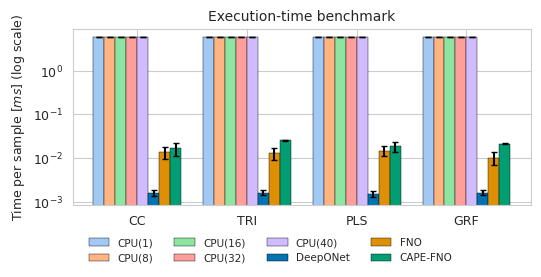

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. DATA (all in ms) ──────────────────────────────────────────
families = ['CC', 'TRI', 'PLS', 'GRF']

means_ms = {
    'CPU(1)' : np.array([5.87, 5.87, 5.87, 5.87]),  # CPU(1) is a constant
    'CPU(8)' : np.array([5.87, 5.87, 5.87, 5.87]),
    'CPU(16)': np.array([5.87, 5.87, 5.87, 5.87]),
    'CPU(32)': np.array([5.87, 5.87, 5.87, 5.87]),
    'CPU(40)': np.array([5.87, 5.87, 5.87, 5.87]),
    # Models
    'DeepONet': np.array([0.00160113, 0.00160004, 0.00153836, 0.00160817]),
    'FNO'     : np.array([0.01356569, 0.01327769, 0.01473285, 0.01014182]),
    'CAPE-FNO': np.array([0.01685495, 0.02564206, 0.01851366, 0.02103266]),
}
stds_ms = {
    'CPU(1)' : np.array([0.05, 0.05, 0.05, 0.05]),  # CPU(1) is a constant
    'CPU(8)' : np.array([0.05, 0.05, 0.05, 0.05]),
    'CPU(16)': np.array([0.05, 0.05, 0.05, 0.05]),
    'CPU(32)': np.array([0.05, 0.05, 0.05, 0.05]),
    'CPU(40)': np.array([0.05, 0.05, 0.05, 0.05]),
    # Models
    'DeepONet': np.array([0.00024832, 0.00021008, 0.00023807, 0.00021681]),
    'FNO'     : np.array([0.00394258, 0.00406557, 0.00383702, 0.00320999]),
    'CAPE-FNO': np.array([0.00547225, 0.00066192, 0.00505883, 0.00051143]),
}

# ── 2. FIGURE SIZE: width 140 mm ────────────────────────────────
mm_to_in = 1 / 25.4
fig_w, fig_h = 140 * mm_to_in, 140 * mm_to_in * 0.45  # 45 % height
# sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# ── 3. GROUPED BAR PLOT (log-scale) ─────────────────────────────
all_labels = list(means_ms.keys())
palette    = (sns.color_palette("pastel", 5) +
              sns.color_palette("colorblind",  3))
n_bars  = len(all_labels)
bar_w   = 0.8 / n_bars
x       = np.arange(len(families))

for i, lbl in enumerate(all_labels):

    data, errs = means_ms[lbl],   stds_ms[lbl]

    ax.bar(x + (i - (n_bars-1)/2)*bar_w, data,
           yerr=errs, width=bar_w,
           color=palette[i], edgecolor='black', linewidth=0.3,
           capsize=2.5, label=lbl)

ax.set_yscale('log')
ax.set_ylabel("Time per sample [$ms$] (log scale)", fontsize=9)
ax.tick_params(axis='y', labelsize=9)  # y-tick labels size
ax.set_xticks(x)
ax.set_xticklabels(families, fontsize=9)
ax.set_title("Execution-time benchmark", fontsize=10)

# ── 4. LEGEND centred *beneath* the plot ───────────────────────
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',  ncol=4, fontsize=7.5,
           bbox_to_anchor=(0.5, -0.12),           # tweak vertical offset here
           frameon=False)

fig.tight_layout()
plt.show()
